# **01 ChromaDB로 만드는 기본 RAG**

### 학습 내용
1. 문서 로딩 및 분할 (Semantic Chunking)
2. ChromaDB 벡터스토어 구축
3. 임베딩 및 유사도 검색
4. ParentDocumentRetriever (Chunk 검색 --> Page)
5. LangGraph를 활용한 RAG 파이프라인 구성
6. Retriever Tool 기반 에이전트 구현

## 1. 환경 변수 설정

- OpenAI API Key 발급: https://platform.openai.com/api-keys

In [41]:
import os
from dotenv import load_dotenv

load_dotenv()

if os.environ.get("OPENAI_API_KEY"):
    print("API Key가 설정되었습니다.")

API Key가 설정되었습니다.


## 2. 문서 로딩 및 Chunking

PDF 문서 출처: https://spri.kr/posts/view/23964?code=AI-Brief&s_year=&data_page=1

In [42]:
import fitz

file_path = "dataset/SPRi AI Brief 4월호_260401.pdf"

doc = fitz.open(file_path)
print(f"총 {len(doc)}페이지 로드 완료")

총 29페이지 로드 완료


In [43]:
# sort=True로 정렬
page = doc[11]
sorted_text = page.get_text("text", sort=True)

print(sorted_text)
print("\n문자 수:", len(sorted_text))

doc.close()

SPRi
AI    오픈AI, AI의 악의적 사용을 다룬 사례 연구 보고서 발간
Brief
        KEY Contents
 2
 0        오픈AI가 중국러시아동남아의,         ,     위협 행위자에 의한 자사 AI 모델을 악의적으로 활용한 주요 2
 6        사례를 종합한 ‘AI의 악의적 사용 차단보고서를’     발간년
 4        보고서에 따르면 위협 행위자들은 모두 AI로 생성된 콘텐츠를 이용했지만콘텐츠,    자체보다는월
호        콘텐츠를 게시한 계정의 인기와 영향력목표를,    겨냥한 광고 등이 성과에 더 결정적 영향을 발휘


            AI 기반 위협 행위, AI와 전통적 수단을 결합하고 복수의 플랫폼을 활용

      오픈AI(OpenAI)가 2026년 2월 25일 자사 AI 모델의 악의적 사용을 탐지하고 예방하기 위한
        사례 연구를 담은 ‘AI의 악의적 사용 차단보고서를’     발표

       사례 연구에 따르면 위협 행위자들은 AI를 단독으로 사용하는 경우는 거의 없으며웹사이트나,       SNS
         계정과 같은 전통적인 도구와 AI를 결합하여 함께 사용

       또한 위협 활동이 하나의 플랫폼에 국한되는 경우도 거의 없고 복수의 플랫폼을 통해 이루어지며,
         하나의 AI 모델에만 의존하는 대신 운영 과정의 여러 단계에서 서로 다른 AI 모델을 활용

     오픈는AI 중국 법 집행 기관과 연계된 챗GPT 계정을 차단한 사례를 집중적으로 다루면서이,  계정이
        수십 개 플랫폼에 걸친 수천 개의 가짜 계정을 동원해 ‘사이버 특수작전을’ 운영했다고 설명

       이 계정은 반체제 인사 신고문서,  위조미국,  관리 사칭 등 수십 가지의 전술을 구사했으며일본,  총리를
         겨냥한 비밀 여론공작은 모델의 거부로 실행에 실패했으나 이후 다른 방식으로 작전을 독자적으로 실행

      또 다른 핵심 사례는

> **💡 Langchain Document 형식 확인하기**

```python
from langchain_core.documents import Document

document = Document(
    page_content="Hello, world!", metadata={"source": "https://example.com"}
)
```

In [45]:
from langchain_core.documents import Document
import fitz

file_path = "dataset/SPRi AI Brief 4월호_260401.pdf"

doc = fitz.open(file_path)
docs = []

for page_num in range(len(doc)):
    page = doc[page_num]
    text = page.get_text("text", sort=True)

    # Langchain Document 형식으로 변환
    docs.append(
        Document(
            page_content=text,
            metadata={
                "source": file_path,
                "page": page_num + 1  # 1부터 시작
            }
        )
    )

doc.close()

In [46]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# child_splitter만 정의
child_splitter = RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=50)

print(f"페이지(parent) 문서 수: {len(docs)}")
print(f"child_splitter chunk_size: {child_splitter._chunk_size}")

페이지(parent) 문서 수: 29
child_splitter chunk_size: 400


In [47]:
print(f"총 {len(docs)}개 만큼의 문서로 청킹되었습니다.")
print([len(i.page_content) for i in docs])

# 각 청크의 메타데이터 및 내용 출력
for i in docs:
    print(i.metadata)       # 문서의 메타데이터 출력 (예: 페이지 번호 등)
    print(i.page_content)   # 분할된 청크의 내용 출력
    print("-" * 100)        # 구분선 출력

총 29개 만큼의 문서로 청킹되었습니다.
[3, 1743, 3581, 257, 3027, 2185, 3361, 2069, 3128, 2197, 52, 2006, 3060, 2143, 2671, 1796, 2986, 2257, 52, 2311, 2948, 1715, 52, 1998, 2908, 2059, 3039, 3414, 2]
{'source': 'dataset/SPRi AI Brief 4월호_260401.pdf', 'page': 1}
4월호
----------------------------------------------------------------------------------------------------
{'source': 'dataset/SPRi AI Brief 4월호_260401.pdf', 'page': 2}
Ⅰ2026Ⅰ2026년 1년월호4 월호Ⅰ Ⅰ





  월간AI모델현황   ∙ 2026년 3월 월간 AI 모델 현황                                        1


            ∙중국과학기술의,      자립자강 강조한 제 15차 5개년 규획 발표                    3
   정책          ∙ OECD, 에이전틱 AI의 개념과 도입 현황을 다룬 보고서 발표                   4
      ･
   법제      ∙미국 국립연구소들 , ‘제네시스 미션수행을’    위해 AI 인프라 확대 추진             5
              ∙미국 뉴욕주, AI 챗봇의 전문직 사칭 금지 법안 추진                         6

                       ∙ 미국 법원앤트로픽을,      공급망 위험으로 지정한 국방부 조치에 제동              7

              ∙미국 트럼프 대통령국가,     AI 입법 프레임워크 발표                          8



                     

## 3. ChromaDB 벡터스토어 구축

ChromaDB는 오픈소스 벡터 데이터베이스로, 문서를 벡터로 변환하여 저장하고 유사도 검색을 수행합니다.

In [67]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings


# 벡터스토어 (child chunk 임베딩 저장)
vectorstore = Chroma(
    collection_name="april_doc",
    embedding_function=OpenAIEmbeddings(),
    persist_directory="./chroma_db"
)

In [68]:
vectorstore

### Retriever 생성

Retriever는 벡터스토어를 래핑하여 검색 기능을 제공하는 인터페이스입니다.

In [69]:
from langchain_classic.retrievers import ParentDocumentRetriever
from langchain_core.stores import InMemoryByteStore

# docstore (parent 페이지 원본 저장)
docstore = InMemoryByteStore()

In [70]:
# ParentDocumentRetriever 생성
parent_retriever = ParentDocumentRetriever(
    vectorstore=vectorstore,
    docstore=docstore,
    child_splitter=child_splitter,
    parent_splitter=None,  # 페이지 = parent
    search_kwargs={"k": 1}
)

In [71]:
# 문서 추가 (내부에서 자동으로 child chunk 생성 → vectorstore, parent page → docstore)
parent_retriever.add_documents(docs)

In [72]:
child_count = vectorstore._collection.count()
parent_count = len(list(docstore.yield_keys()))
print(f"child chunk 수 (vectorstore): {child_count}")
print(f"parent page 수 (docstore): {parent_count}")
print(f"\n구조: page(parent) → chunk(child)")
print(f"평균 chunk/page: {child_count / parent_count:.1f}")

child chunk 수 (vectorstore): 198
parent page 수 (docstore): 29

구조: page(parent) → chunk(child)
평균 chunk/page: 6.8


## 4. 유사도 검색 테스트

- vectorstore(Chroma)의 similarity_search : vectorstore에 저장된 chunk 그대로 반환

In [73]:
# 검색 쿼리
query = "전문직을 사칭한 AI관련 법안"

# 유사도 검색 (k=3: 가장 유사한 문서 3개 반환)
results = vectorstore.similarity_search(query, k=3)

for i, result in enumerate(results, start=1):
    print(f"\n[관련 문서 {i}]")
    print(result.page_content)


[관련 문서 1]
SPRi
AI    미국 뉴욕주 , AI 챗봇의 전문직 사칭 금지 법안 추진
Brief
        KEY Contents
 2
 0
 2        미국 뉴욕주 상원은 AI 챗봇이 변호사나 의사 등 면허가 필요한 전문직을 사칭하거나 이에 준하는
 6
년        실질적 조언을 제공하는 행위를 금지하는 법안을 추진
 4
월              AI 챗봇 운영자는 사용자에게 AI와 대화 중임을 명확히 알려야 하며위반,   행위로 피해를 입은
호
         사용자는 민사 소송을 통해 손해 배상과 소송 비용을 청구 가능


          S7263 법안면허,   전문직을 사칭한 AI 챗봇의 조언 제공 금지

[관련 문서 2]
법안에 따르면 개인은 동 법안의 규정을 위반한 AI 챗봇 운영사를 대상으로 민사 소송을 제기할 수 있으며,
         피해자가 챗봇의 무허가 조언 제공 사실을 입증하면 손해 배상과 소송 비용을 청구 가능

      동 법안은 AI 챗봇 규제를 위한 포괄적인 법안 패키지의 일부로기타,   법안은 AI 챗봇과 대화하는
        미성년자 보호 및 생성형 AI 시스템과 합성 미디어에 대한 투명성 강화 등을 규정

                 S7263 법안은 2026년 2월 25일 뉴욕주 상원 인터넷기술위원회를·      만장일치로 통과하고 3차 독회
        이후 본회의 표결을 남겨두고 있으며법,  시행일은 공포 후 90일로 규정

[관련 문서 3]
 AI 챗봇의 사칭이 금지된 전문직은 의사치과의사물리치료사,            ,     등 뉴욕주 교육법상 면허 관련 조항이
         적용되는 직종 및 변호사법의 적용을 받는 무면허 법률행위 전반을 포괄
                 AI 챗봇 운영자*는 사용자에게 AI와 대화 중임을 명확하게 고지해야 하며고지,  문구는 챗봇이 사용하는
         언어와 동일한 언어를 사용해 화면 내 표시되는 글자 크기 중 최대 이상의 

- 반환: 페이지 전체 (큰 context)

In [74]:
# ParentDocumentRetriever 검색 테스트
# chunk로 검색하되, 반환은 해당 chunk가 속한 페이지 전체
relevant_docs = parent_retriever.invoke(query)

print(f"[검색 결과: {len(relevant_docs)}개 페이지 반환]")
for i, doc in enumerate(relevant_docs):
    print(f"\n--- 페이지 {doc.metadata.get('page', '?')} ---")
    print(f"길이: {len(doc.page_content)}자")
    print(doc.page_content)

[검색 결과: 1개 페이지 반환]

--- 페이지 8 ---
길이: 2069자
SPRi
AI    미국 뉴욕주 , AI 챗봇의 전문직 사칭 금지 법안 추진
Brief
        KEY Contents
 2
 0
 2        미국 뉴욕주 상원은 AI 챗봇이 변호사나 의사 등 면허가 필요한 전문직을 사칭하거나 이에 준하는
 6
년        실질적 조언을 제공하는 행위를 금지하는 법안을 추진
 4
월              AI 챗봇 운영자는 사용자에게 AI와 대화 중임을 명확히 알려야 하며위반,   행위로 피해를 입은
호
         사용자는 민사 소송을 통해 손해 배상과 소송 비용을 청구 가능


          S7263 법안면허,   전문직을 사칭한 AI 챗봇의 조언 제공 금지

      미국 뉴욕주 상원에서 AI 챗봇이 면허를 소지한 전문가처럼 행동하여 사용자에게 해를 끼칠 수 있는
        실질적 답변을 제공하는 행위를 금지하는 ‘S7263’ 법안이 본회의 표결을 앞둔 상태

                 AI 챗봇의 사칭이 금지된 전문직은 의사치과의사물리치료사,            ,     등 뉴욕주 교육법상 면허 관련 조항이
         적용되는 직종 및 변호사법의 적용을 받는 무면허 법률행위 전반을 포괄
                 AI 챗봇 운영자*는 사용자에게 AI와 대화 중임을 명확하게 고지해야 하며고지,  문구는 챗봇이 사용하는
         언어와 동일한 언어를 사용해 화면 내 표시되는 글자 크기 중 최대 이상의 크기로 표시 필요
                  * AI 챗봇을 소유운영배포하는·     ·    개인기업기관,       ,   등을 의미하며기술,   라이선스만 제공하는 제자3 개발사는 제외

        법안에 따르면 개인은 동 법안의 규정을 위반한 AI 챗봇 운영사를 대상으로 민사 소송을 제기할 수 있으며,
         피해자가 챗봇의 무허가 조언 제공 사실을 입증하면 손해 배

In [62]:
relevant_docs[0].metadata

{'source': 'dataset/SPRi AI Brief 4월호_260401.pdf', 'page': 8}

In [63]:
relevant_docs[0].page_content

'SPRi\nAI    미국 뉴욕주 , AI 챗봇의 전문직 사칭 금지 법안 추진\nBrief\n        KEY Contents\n 2\n 0\n 2        미국 뉴욕주 상원은 AI 챗봇이 변호사나 의사 등 면허가 필요한 전문직을 사칭하거나 이에 준하는\n 6\n년        실질적 조언을 제공하는 행위를 금지하는 법안을 추진\n 4\n월              AI 챗봇 운영자는 사용자에게 AI와 대화 중임을 명확히 알려야 하며위반,   행위로 피해를 입은\n호\n         사용자는 민사 소송을 통해 손해 배상과 소송 비용을 청구 가능\n\n\n          S7263 법안면허,   전문직을 사칭한 AI 챗봇의 조언 제공 금지\n\n      \uf06e미국 뉴욕주 상원에서 AI 챗봇이 면허를 소지한 전문가처럼 행동하여 사용자에게 해를 끼칠 수 있는\n        실질적 답변을 제공하는 행위를 금지하는 ‘S7263’ 법안이 본회의 표결을 앞둔 상태\n\n                \uf09f AI 챗봇의 사칭이 금지된 전문직은 의사치과의사물리치료사,            ,     등 뉴욕주 교육법상 면허 관련 조항이\n         적용되는 직종 및 변호사법의 적용을 받는 무면허 법률행위 전반을 포괄\n                \uf09f AI 챗봇 운영자*는 사용자에게 AI와 대화 중임을 명확하게 고지해야 하며고지,  문구는 챗봇이 사용하는\n         언어와 동일한 언어를 사용해 화면 내 표시되는 글자 크기 중 최대 이상의 크기로 표시 필요\n                  * AI 챗봇을 소유운영배포하는·     ·    개인기업기관,       ,   등을 의미하며기술,   라이선스만 제공하는 제자3 개발사는 제외\n\n        \uf09f법안에 따르면 개인은 동 법안의 규정을 위반한 AI 챗봇 운영사를 대상으로 민사 소송을 제기할 수 있으며,\n         피해자가 챗봇의 무허가 조언 제공 사실을 입증하면 

## 6. LangGraph를 활용한 RAG 파이프라인 구성

LangGraph를 사용하여 Retriever → Answer 흐름을 그래프로 구성합니다.

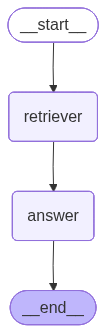

### Step 1: State 정의

In [76]:
from langgraph.graph import StateGraph, MessagesState

class State(MessagesState): # MessagesState: messages 키 , add_messages() 리듀서 함수로 활용
    """
    RAG 파이프라인의 상태를 정의합니다.

    Attributes:
        messages (list): 메시지 목록
        context (str): 검색된 문서 내용
    """
    context: str

# StateGraph 초기화
graph_builder = StateGraph(State)

### Step 2: Node 정의

In [77]:
docs[10].metadata

{'source': 'dataset/SPRi AI Brief 4월호_260401.pdf', 'page': 11}

In [78]:
from langchain_core.messages import HumanMessage

def retriever(state: State):
    """
    ParentDocumentRetriever를 사용하여 검색.
    chunk로 유사도 검색 → 해당 chunk가 속한 페이지 전체를 반환.
    """
    print("##### RETRIEVER (ParentDocumentRetriever) #####")

    query = state["messages"][0].content

    # ParentDocumentRetriever: chunk로 검색, 페이지 전체 반환
    results = parent_retriever.invoke(query)

    # context 구성 (페이지 단위)
    context_parts = []
    for doc in results:
        page_num = doc.metadata.get("page", "?")
        context_parts.append(f"[페이지 {page_num}]\n{doc.page_content}")

    final_content = "\n\n---\n\n".join(context_parts)

    print(f"[반환된 페이지 수] {len(results)}")
    for doc in results:
        print(f"  - 페이지 {doc.metadata.get('page', '?')} ({len(doc.page_content)}자)")
    print(f"[미리보기]\n{final_content[:200]}...\n")

    return {
        "context": final_content,
        "messages": [HumanMessage(content=final_content)]
    }

In [79]:
from langchain.chat_models import init_chat_model
from langchain_classic import hub
from langchain.messages import HumanMessage, SystemMessage

llm = init_chat_model("gpt-4o-mini")

def answer(state: State):
    """
    검색된 문서를 기반으로 사용자 질문에 답변합니다.
    """
    print("##### ANSWER #####")
    query = state["messages"][0].content
    context = state["messages"][-1].content
    # context = state["context"]

    SYSTEM_PROMPT = f"""
    당신은 관련 문서를 기반으로 답변하는 어시스턴트입니다.
    주어진 문서 텍스트를 기반으로 사용자의 질문에 대해 충실히 답변하세요.
    답변은 마크다운 문법 형식으로 적절한 볼드체, 제목, 불렛 등을 사용하여 가독성 좋게 작성하세요.
    """
    system_msg = SystemMessage(SYSTEM_PROMPT)
    human_msg = HumanMessage(f"""
    다음은 주어진 문서 텍스트입니다.
    <context>
    {context}
    </context>

    <question>
    {query}
    </question>
    """)

    response = llm.invoke(
        [system_msg, human_msg]
    )

    print(f"[생성된 답변]\n{response.content}\n")

    return {"messages": [response]} # AIMessage

### Step 3: Graph 구성 및 컴파일

In [80]:
from langgraph.graph import START, END

# 노드 추가 및 연결
graph_builder.add_sequence([retriever, answer])
graph_builder.add_edge(START, "retriever")
graph_builder.add_edge("answer", END)

# 그래프 컴파일
graph = graph_builder.compile()

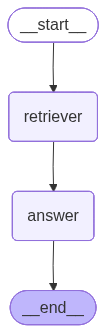

In [81]:
# 그래프 시각화
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

### Step 4: RAG 파이프라인 실행

In [82]:
from langchain_core.messages import AIMessageChunk

user_message = HumanMessage("전문직을 사칭한 AI관련 법안 ")

final_answer = ""
for chunk_msg, metadata in graph.stream({"messages": [user_message]}, stream_mode="messages"):
    print(chunk_msg.content, end="", flush=True)
    if type(chunk_msg) == AIMessageChunk:
        final_answer += chunk_msg.content

##### RETRIEVER (ParentDocumentRetriever) #####
[반환된 페이지 수] 1
  - 페이지 8 (2069자)
[미리보기]
[페이지 8]
SPRi
AI    미국 뉴욕주 , AI 챗봇의 전문직 사칭 금지 법안 추진
Brief
        KEY Contents
 2
 0
 2        미국 뉴욕주 상원은 AI 챗봇이 변호사나 의사 등 면허가 필요한 전문직을 사칭하거나 이에 준하는
 6
년        실질적 조언을 제공하는 행위를 금지하는 법안을 추진
 4
월       ...

[페이지 8]
SPRi
AI    미국 뉴욕주 , AI 챗봇의 전문직 사칭 금지 법안 추진
Brief
        KEY Contents
 2
 0
 2        미국 뉴욕주 상원은 AI 챗봇이 변호사나 의사 등 면허가 필요한 전문직을 사칭하거나 이에 준하는
 6
년        실질적 조언을 제공하는 행위를 금지하는 법안을 추진
 4
월              AI 챗봇 운영자는 사용자에게 AI와 대화 중임을 명확히 알려야 하며위반,   행위로 피해를 입은
호
         사용자는 민사 소송을 통해 손해 배상과 소송 비용을 청구 가능


          S7263 법안면허,   전문직을 사칭한 AI 챗봇의 조언 제공 금지

      미국 뉴욕주 상원에서 AI 챗봇이 면허를 소지한 전문가처럼 행동하여 사용자에게 해를 끼칠 수 있는
        실질적 답변을 제공하는 행위를 금지하는 ‘S7263’ 법안이 본회의 표결을 앞둔 상태

                 AI 챗봇의 사칭이 금지된 전문직은 의사치과의사물리치료사,            ,     등 뉴욕주 교육법상 면허 관련 조항이
         적용되는 직종 및 변호사법의 적용을 받는 무면허 법률행위 전반을 포괄
                 AI 챗봇 운영자*는 사용자에게 AI와 대화 중임을 명확하게 고지해야 하며고지,  문구는 챗봇이 사용하는
         언어와 동일

In [83]:
from IPython.display import Markdown

display(Markdown(final_answer))

# 전문직을 사칭한 AI 관련 법안: 뉴욕주 S7263 법안

**개요**
- 뉴욕주 상원은 AI 챗봇이 변호사, 의사 등 면허가 필요한 전문직을 사칭하거나 실질적인 조언을 제공하는 행위를 금지하는 **S7263 법안**을 추진하고 있습니다.

## **법안의 주요 내용**
- **사칭 금지 직종**: 
    - 의사, 치과의사, 물리치료사 등 전문직
    - 변호사법의 적용을 받는 무면허 법률행위 포함

- **AI 챗봇 운영자의 의무**:
    - 사용자에게 AI와 대화 중임을 명확히 알려야 함
    - 고지 문구는 챗봇이 사용하는 언어와 동일해야 하며, 화면 내 글자 크기는 최대 이상의 크기로 표시 필요

- **민사 소송**:
    - 법안 위반 시 피해자는 AI 챗봇 운영사를 상대로 민사 소송을 제기할 수 있으며, 손해 배상 및 소송 비용 청구 가능

## **법안 통과 현황**
- S7263 법안은 **2026년 2월 25일** 뉴욕주 상원 인터넷 기술위원회에서 만장일치로 통과
- 본회의 표결을 남겨두고 있으며, 시행일은 공포 후 90일로 예정

## **법안의 필요성**
- 법률 및 의료 분야에서 AI 챗봇의 활용 증가와 실제 피해 사례가 잇달아 발생
    - 예: ChatGPT가 무면허 법률 서비스를 제공하여 소송을 제기당한 사건
- 입법 필요성이 증대되고 있으나, 허용과 금지의 경계가 불분명해 논란 가능성 존재

## **결론**
S7263 법안은 AI 챗봇이 전문직을 사칭하여 사용자에게 해를 끼칠 수 있는 행위를 방지하기 위한 중요한 조치로 볼 수 있으며, AI 기술의 발전과 함께 그 필요성이 더욱 강조되고 있습니다.

In [84]:
user_message = HumanMessage("앤트로픽이 분석한 AI 의 영향력")

for chunk in graph.stream({"messages": [user_message]}, stream_mode="updates"):
    print("\n=== 업데이트 ===")
    for node, value in chunk.items():
        print(f"노드: {node}")
        if "messages" in value:
            for msg in value["messages"]:
                print(f"내용: {msg.content}")

##### RETRIEVER (ParentDocumentRetriever) #####
[반환된 페이지 수] 1
  - 페이지 20 (2311자)
[미리보기]
[페이지 20]
SPRi
AI    앤트로픽사용자의,        AI 활용 능력을 측정한 ‘AI 능숙도 지수공개’
Brief
        KEY Contents
 2
 0        앤트로픽이 9,830건의 클로드 대화를 분석해 사용자가 AI를 얼마나 효과적으로 활용하는지를 2
 6        측정한 ‘AI 능숙도 지수(AI Fluency Index...


=== 업데이트 ===
노드: retriever
내용: [페이지 20]
SPRi
AI    앤트로픽사용자의,        AI 활용 능력을 측정한 ‘AI 능숙도 지수공개’
Brief
        KEY Contents
 2
 0        앤트로픽이 9,830건의 클로드 대화를 분석해 사용자가 AI를 얼마나 효과적으로 활용하는지를 2
 6        측정한 ‘AI 능숙도 지수(AI Fluency Index)’ 를 공개년
 4        분석 결과대화를,    통해 결과물을 반복적으로 다듬는 사용자들은 그렇지 않은 사용자 대비 AI월
호        능숙도가 두 배 이상 더 높고, AI의 논리를 비판적으로 검토하는 비율도 훨씬 높은 것으로 확인


            AI 능숙도의 핵심 지표는 AI 생성물에 대한 반복 질문과 개선 시도

       앤트로픽이 2026년 2월 23일 Claude.ai에서 이루어진 9,830건의 대화를 바탕으로 사용자의
                AI 활용 능력을 측정한 ‘AI 능숙도 지수(Fluency Index)’를 공개

        앤트로픽은 이번 연구를 위해 ‘4D AI 능숙도 프레임워크를’ 개발하고 안전하고 효과적인 인간-AI 협업을
         규정한 24개의 구체적 행동 지표를 정의했으며분석,   대상은 직접 관찰 가능한 11개 항목*으로 한정

                  *

In [85]:
from IPython.display import Markdown

display(Markdown(msg.content))

# 앤트로픽이 분석한 AI의 영향력

앤트로픽은 AI의 활용 능력을 측정하기 위해 **'AI 능숙도 지수(AI Fluency Index)'**를 공개하였습니다. 다음은 이 연구의 주요 내용과 AI의 영향력에 관한 분석 결과입니다.

## 연구 개요
- **분석 대화 수**: 9,830건의 클로드 대화를 기반으로 진행
- **핵심 지표**: AI 생성물에 대한 반복 질문과 개선 시도를 통해 AI 활용 능력을 평가

## 주요 발견
- **반복적인 정교화**: 전체 대화의 **85.7%**에서 AI가 생성한 결과물을 다듬는 행동이 나타나며, 이러한 행동이 관찰된 대화는 AI 능숙도가 두 배 높음.
- **비판적 사고**: 반복과 정교화를 거친 대화에서는 사용자가 클로드의 추론 과정에 대해 질문할 가능성이 **5.6배** 더 높았고, 부족한 맥락을 지적할 가능성도 **4배** 증가.
- **AI 결과물 생성**: 대화의 **12.3%**가 코드나 문서와 같은 아티팩트를 생성하는 데 관련되어 있으며, 목표 명확화와 형식 지정 등의 능숙도 행동이 유의미하게 증가.

## 비판적 평가의 중요성
- 연구에서는 AI가 생성한 정교한 결과물에 대해 검증을 소홀히 하는 경향이 있으며, 이는 비판적 평가 능력이 더욱 중요함을 시사합니다. 
- AI의 초기 응답을 그대로 수용하기보다는, 지속적인 질문과 반론 제기를 통해 대화를 이어가는 방식이 AI 활용 능력에 긍정적인 영향을 미친다고 강조.

## 향후 연구 방향
- 새로운 사용자와 기존 사용자의 비교 분석을 통해 AI에 대한 친숙성이 능숙도 발달에 미치는 영향을 파악할 예정.
- AI 대화에서 직접 관찰되지 않는 행동 양상을 질적 연구를 통해 분석 계획.
- AI 능숙도와 반복적 대화 간의 인과관계를 탐색하고, 비판적 평가 능력 향상을 위한 효과적인 유도 방안을 모색할 계획.

이 연구는 AI 활용 능력이 시간에 따라 어떻게 변화하는지에 대한 기준점으로 활용될 것으로 기대됩니다.

### 📖 과제 1: 시스템 프롬프트로 RAG 성능 향상 및 지침 제어하기

SYSTEM_PROMPT 를 수정하여 답변의 성능을 높여보세요. (참고한 문서의 출처 표기, 구조화 답변 등등)

---

## 7. Retriever Tool 기반 에이전트 구현

Retriever를 Tool로 정의하여 에이전트가 필요할 때만 문서를 검색하도록 합니다.

### Step 1: Retriever Tool 생성

In [86]:
from langchain_core.tools import create_retriever_tool

retriever_tool = create_retriever_tool(
    parent_retriever,
    "retrieve_AI_brief",
    "Search and return information about AI Technology and Industry from SPRi AI Brief.",
)

tools = [retriever_tool]
print("Retriever Tool이 생성되었습니다.")

Retriever Tool이 생성되었습니다.


### Step 2: Graph 구성

In [87]:
from langgraph.graph import StateGraph, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition

# 새로운 Graph Builder 생성
graph_builder = StateGraph(MessagesState)

# Tool Node 추가
tool_node = ToolNode(tools=tools)
graph_builder.add_node("retriever", tool_node)

In [88]:
# LLM에 도구 바인딩
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: MessagesState):
    """
    LLM이 사용자 질문을 분석하고 필요시 도구를 호출합니다.
    """
    return {"messages": [llm_with_tools.invoke(state["messages"])]} # tool_calls or AIMessage

graph_builder.add_node("chatbot", chatbot)

**tools_condition**: 마지막 메시지에 tool_calls가 있으면 ToolNode로 라우팅, 없으면 END로 이동

In [89]:
# 조건부 엣지 추가
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
    {
        "tools": "retriever",
        END: END
    }
)

# Answer 노드 추가
graph_builder.add_node("answer", answer)

# 엣지 연결
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("retriever", "answer")
graph_builder.add_edge("answer", END)

# 그래프 컴파일
graph = graph_builder.compile()

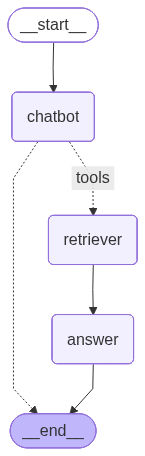

In [90]:
# 그래프 시각화
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

### Step 3: 에이전트 실행 테스트

In [91]:
# 문서 검색이 필요한 질문
response = graph.invoke({
    "messages": "앤트로픽이 분석한 AI의 영향력"
})

print("\n" + "=" * 80)
print("[에이전트 실행 결과 - 문서 검색 필요]")
print("=" * 80)
for msg in response['messages']:
    msg.pretty_print()

##### ANSWER #####
[생성된 답변]
# 앤트로픽이 분석한 AI의 영향력

**주요 내용 요약:**

- **AI의 실제 업무 활용 정도**: 
  - 이론적인 가능성에 비해 실제 AI 활용도는 낮음. 예를 들어, 컴퓨터 프로그래머의 AI 노출도가 높은 편이나, 조사된 데이터에 따르면 AI 보조적 업무의 비율은 33%에 불과함.
  
- **노동 시장의 변화**:
  - AI 기술이 노출도가 높은 직종에서 실업률 증가가 관찰되지 않음. 그러나 22~25세 청년층의 신규 취업률이 둔화되고 있음.
  
- **관측 노출도 지표**:
  - AI가 이론적으로 처리할 수 있는 업무 중 실제 활용되는 비율을 기준으로, 800개 직무를 분석하여 '관측 노출도'를 도출함.
  - 예: 컴퓨터 프로그래머(74.5%), 고객 서비스 담당자(70.1%) 등은 높은 AI 노출도를 보임, 반면 조리사, 정비사 등의 직종은 노출도가 0에 가까움.

- **실업률 변화**:
  - AI 노출도 상위 집단과 하위 집단 간 실업률 차이는 미미함. AI로 인한 명확한 실업 증가 증거는 발견되지 않았으나 청년층의 신규 채용 비율이 둔화되는 경향이 있음.
  
- **향후 연구 방향**:
  - 신규 고용 및 AI 사용 데이터를 축적하면서 AI의 노동 시장에 미치는 영향을 명확히 분석할 수 있을 것으로 전망함. 특히, 고용의 둔화가 기존 인력의 해고보다는 청년층 신규 채용 감소로 나타나고 있을 가능성이 제기됨.

이러한 결과는 AI가 노동 시장에 미치는 영향이 복잡하고 다양한 양상으로 나타났음을 보여줍니다.


[에이전트 실행 결과 - 문서 검색 필요]
================================ Human Message =================================

앤트로픽이 분석한 AI의 영향력
================================== Ai Message ==================================
Tool 

In [92]:
# 문서 검색이 불필요한 일반 대화
for chunk in graph.stream({"messages": "안녕하세요, 반갑습니다!"}):
    for node, value in chunk.items():
        if node:
            print(f"===== {node} =====")
        if "messages" in value:
            print(value['messages'][0].content)
            print()

===== chatbot =====
안녕하세요! 반갑습니다. 어떻게 도와드릴까요?

